In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_excel("../data/raw/Online Retail.xlsx")

In [3]:
df = df.dropna(subset=["CustomerID"])
df = df[df["Quantity"] > 0]

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [5]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [6]:
monthly_sales = df.groupby("Month")["Revenue"].sum()
monthly_sales

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Revenue, dtype: float64

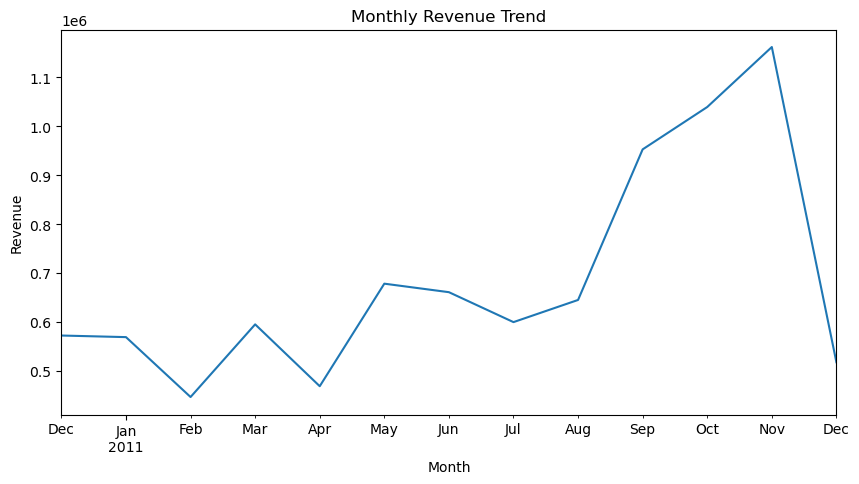

In [7]:
monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [8]:
monthly_sales.index = monthly_sales.index.to_timestamp()

In [9]:
monthly_sales.head()

Month
2010-12-01    572713.890
2011-01-01    569445.040
2011-02-01    447137.350
2011-03-01    595500.760
2011-04-01    469200.361
Freq: MS, Name: Revenue, dtype: float64

In [10]:
train = monthly_sales.iloc[:10]
test = monthly_sales.iloc[10:]

X_train = np.arange(len(train)).reshape(-1,1)
y_train = train.values

X_test = np.arange(len(train), len(train) + len(test)).reshape(-1,1)
y_test = test.values


print(X_train)
print(X_test)

[[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]
[[10]
 [11]
 [12]]


In [11]:
from sklearn.linear_model import LinearRegression

forecast_model = LinearRegression()
forecast_model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = forecast_model.predict(X_test)

In [13]:
print(y_pred)

[789998.35246667 821051.16302424 852103.97358182]


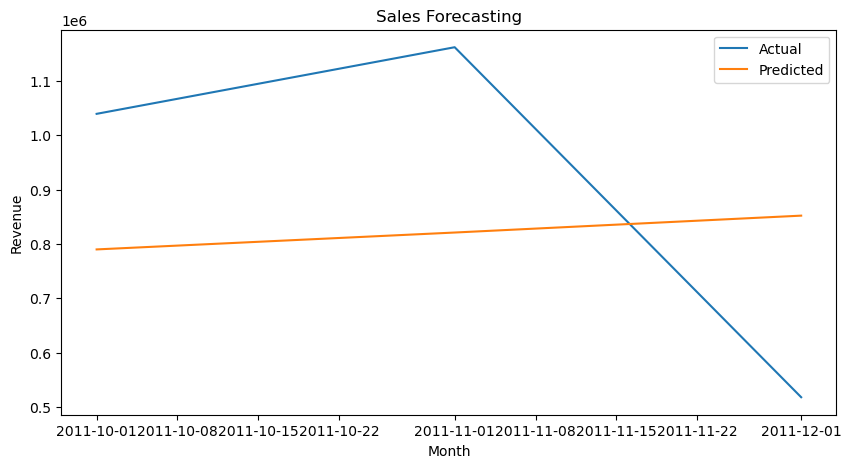

In [14]:
plt.figure(figsize=(10,5))

plt.plot(test.index, y_test, label="Actual")
plt.plot(test.index, y_pred, label="Predicted")

plt.title("Sales Forecasting")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.legend()

plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor

In [16]:
rf_forecast = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [17]:
rf_forecast.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [18]:
y_pred_rf = rf_forecast.predict(X_test)

print(y_pred_rf)

[834257.7145 834257.7145 834257.7145]


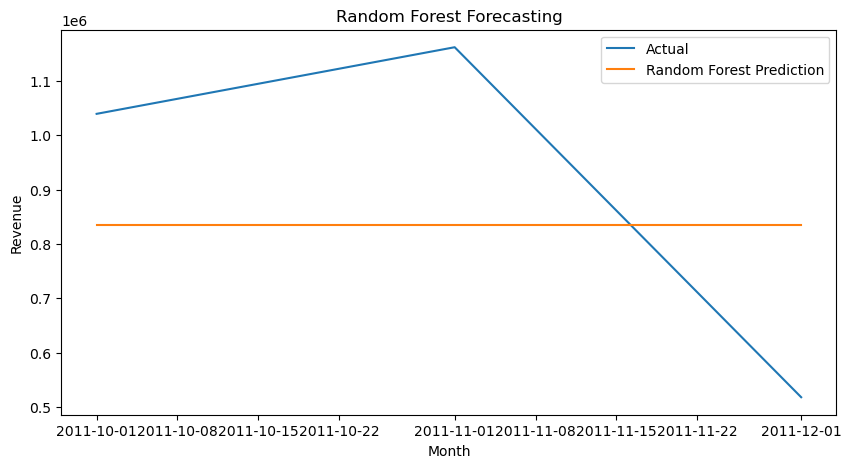

In [19]:
plt.figure(figsize=(10,5))

plt.plot(test.index, y_test, label="Actual")
plt.plot(test.index, y_pred_rf, label="Random Forest Prediction")

plt.title("Random Forest Forecasting")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.legend()

plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error

In [21]:
mae_lr = mean_absolute_error(y_test, y_pred)

print(mae_lr)

307999.2793636364


In [22]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(mae_rf)

282895.22183333343


In [23]:
# Weekly Sales Forecasting

In [24]:
weekly_sales = df.resample("W", on="InvoiceDate")["Revenue"].sum()

weekly_sales.head()

InvoiceDate
2010-12-05    149386.33
2010-12-12    213447.72
2010-12-19    163770.73
2010-12-26     46109.11
2011-01-02         0.00
Freq: W-SUN, Name: Revenue, dtype: float64

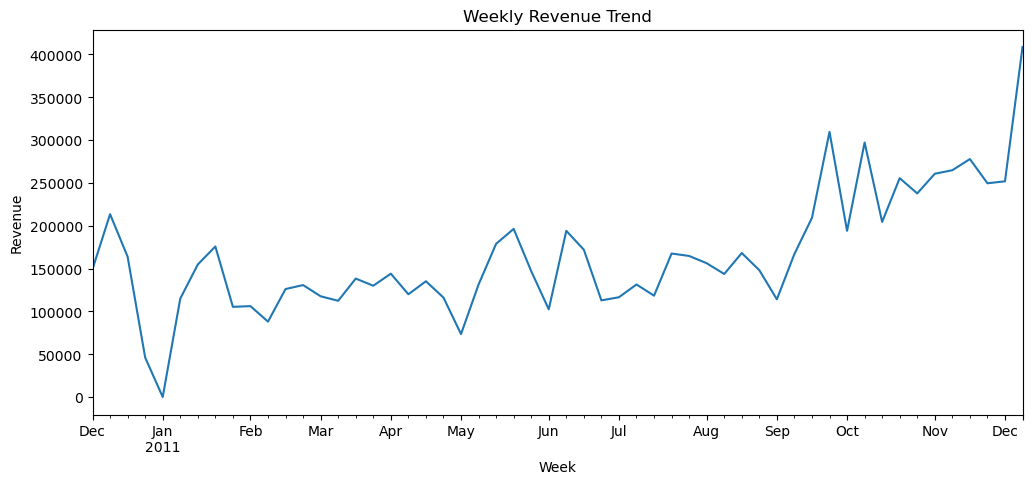

In [25]:
weekly_sales.plot(figsize=(12,5))

plt.title("Weekly Revenue Trend")
plt.xlabel("Week")
plt.ylabel("Revenue")

plt.show()

In [26]:
len(weekly_sales)

54

In [27]:
weekly_train = weekly_sales.iloc[:45]
weekly_test = weekly_sales.iloc[45:]

print(len(weekly_train))
print(len(weekly_test))

45
9


In [28]:
X_train_weekly = np.arange(len(weekly_train)).reshape(-1,1)
y_train_weekly = weekly_train.values

X_test_weekly = np.arange(
    len(weekly_train),
    len(weekly_train) + len(weekly_test)
).reshape(-1,1)

y_test_weekly = weekly_test.values

In [29]:
weekly_lr_model = LinearRegression()

In [30]:
weekly_lr_model.fit(X_train_weekly, y_train_weekly)

LinearRegression()

In [31]:
y_pred_weekly_lr = weekly_lr_model.predict(X_test_weekly)

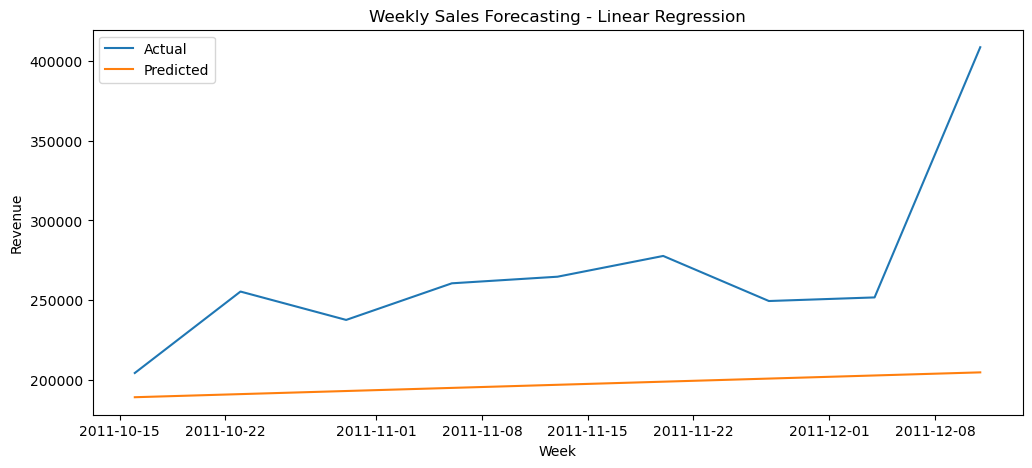

In [32]:
plt.figure(figsize=(12,5))

plt.plot(weekly_test.index, y_test_weekly, label="Actual")
plt.plot(weekly_test.index, y_pred_weekly_lr, label="Predicted")

plt.title("Weekly Sales Forecasting - Linear Regression")
plt.xlabel("Week")
plt.ylabel("Revenue")

plt.legend()

plt.show()

In [33]:
weekly_rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [34]:
weekly_rf_model.fit(X_train_weekly, y_train_weekly)

RandomForestRegressor(n_estimators=200, random_state=42)

In [35]:
y_pred_weekly_rf = weekly_rf_model.predict(X_test_weekly)

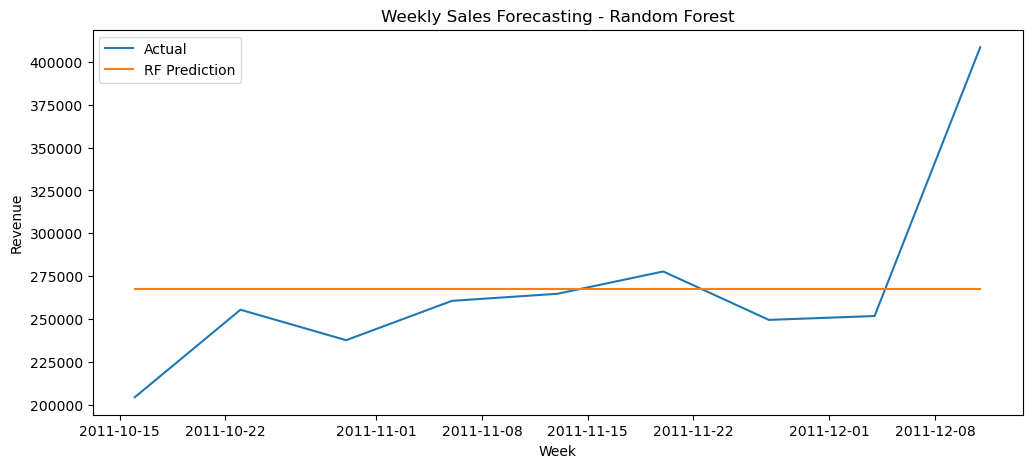

In [36]:
plt.figure(figsize=(12,5))

plt.plot(weekly_test.index, y_test_weekly, label="Actual")
plt.plot(weekly_test.index, y_pred_weekly_rf, label="RF Prediction")

plt.title("Weekly Sales Forecasting - Random Forest")
plt.xlabel("Week")
plt.ylabel("Revenue")

plt.legend()

plt.show()

In [37]:
weekly_df = weekly_sales.to_frame()

In [38]:
weekly_df["Lag_1"] = weekly_df["Revenue"].shift(1)

In [39]:
weekly_df.dropna(inplace=True)

In [40]:
weekly_df.head()

,Revenue,Lag_1
InvoiceDate,,
2010-12-12,213447.72,149386.33
2010-12-19,163770.73,213447.72
2010-12-26,46109.11,163770.73
2011-01-02,0.00,46109.11
2011-01-09,114865.27,0.00


In [41]:
train_size = int(len(weekly_df) * 0.8)

train = weekly_df.iloc[:train_size]
test = weekly_df.iloc[train_size:]

In [42]:
X_train = train[["Lag_1"]]
y_train = train["Revenue"]

X_test = test[["Lag_1"]]
y_test = test["Revenue"]

In [43]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

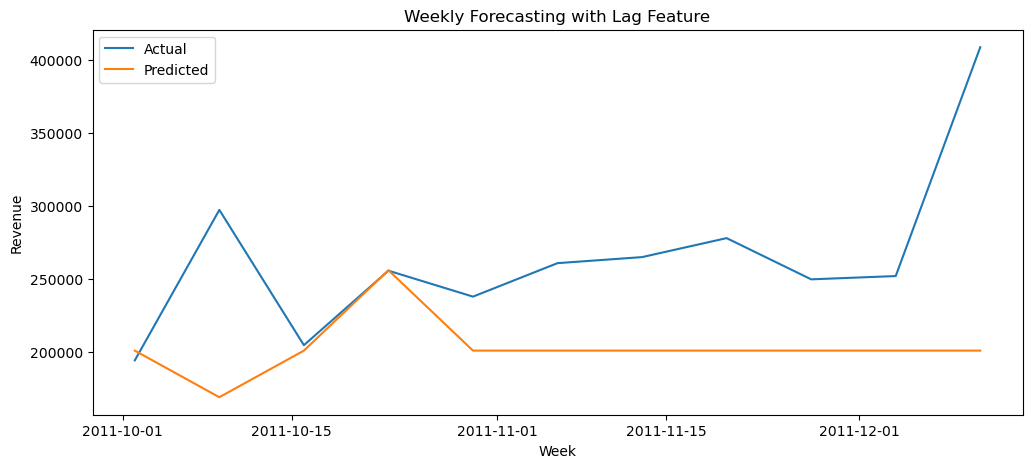

In [44]:
plt.figure(figsize=(12,5))

plt.plot(test.index, y_test, label="Actual")
plt.plot(test.index, y_pred, label="Predicted")

plt.title("Weekly Forecasting with Lag Feature")
plt.xlabel("Week")
plt.ylabel("Revenue")

plt.legend()

plt.show()

In [45]:
weekly_df["Lag_2"] = weekly_df["Revenue"].shift(2)
weekly_df["Lag_3"] = weekly_df["Revenue"].shift(3)

In [46]:
weekly_df.dropna(inplace=True)

In [47]:
weekly_df.head()

,Revenue,Lag_1,Lag_2,Lag_3
InvoiceDate,,,,
2011-01-02,0.00,46109.11,163770.73,213447.72
2011-01-09,114865.27,0.00,46109.11,163770.73
2011-01-16,154714.94,114865.27,0.00,46109.11
2011-01-23,175757.98,154714.94,114865.27,0.00
2011-01-30,105288.77,175757.98,154714.94,114865.27


In [48]:
(weekly_df["Revenue"] == 0).sum()

np.int64(1)

In [49]:
train_size = int(len(weekly_df) * 0.8)

train = weekly_df.iloc[:train_size]
test = weekly_df.iloc[train_size:]

In [50]:
X_train = train[["Lag_1", "Lag_2", "Lag_3"]]
y_train = train["Revenue"]

X_test = test[["Lag_1", "Lag_2", "Lag_3"]]
y_test = test["Revenue"]

In [51]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

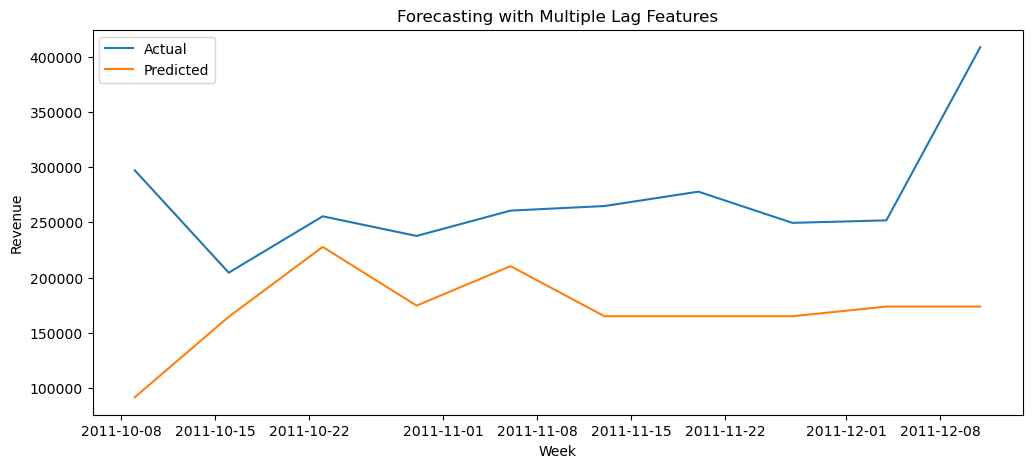

In [52]:
plt.figure(figsize=(12,5))

plt.plot(test.index, y_test, label="Actual")
plt.plot(test.index, y_pred, label="Predicted")

plt.title("Forecasting with Multiple Lag Features")
plt.xlabel("Week")
plt.ylabel("Revenue")

plt.legend()

plt.show()